# LUCY — Módulo 1: BehaviorLSTM
## Cerebro Temporal: Aprende comportamiento humano desde secuencias

Este notebook demuestra que la IA **aprende** patrones de comportamiento.
Sin reglas hardcodeadas. Sin umbrales fijos. La red descubre sola qué hace
a un comportamiento sospechoso observando **secuencias de movimiento**.

### ¿Por qué LSTM y no reglas?
| Enfoque anterior (reglas) | BehaviorLSTM (este módulo) |
|---|---|
| `if tiempo_quieto > 5s → merodeo` | El modelo aprende qué es "mucho tiempo quieto" |
| Umbral fijo: distancia < 0.10 | La red aprende qué distancias son peligrosas |
| No mejora con más datos | Mejora con cada ejemplo nuevo |
| No generaliza | Generaliza a situaciones no vistas |

### Arquitectura
```
Secuencia de 30 frames
  → Proyección lineal (35 → 64 features)
  → BiLSTM bidireccional (2 capas, 128 unidades)
  → Atención Temporal (aprende qué frames importan)
  → Clasificador MLP
  → [normal | loitering | confrontation | encirclement | following | violence]
```

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import torch
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from models.behavior_lstm import BehaviorLSTM, BEHAVIOR_CLASSES, SEQ_LEN, FRAME_FEATS

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {DEVICE}')
print(f'Clases: {BEHAVIOR_CLASSES}')
print(f'Longitud de secuencia: {SEQ_LEN} frames')
print(f'Features por frame: {FRAME_FEATS}')

Dispositivo: cuda
Clases: ['normal', 'loitering', 'confrontation', 'encirclement', 'following', 'violence']
Longitud de secuencia: 30 frames
Features por frame: 35


## 1. Curvas de Aprendizaje
El modelo aprende progresivamente — esto es lo que diferencia la IA real de las reglas.

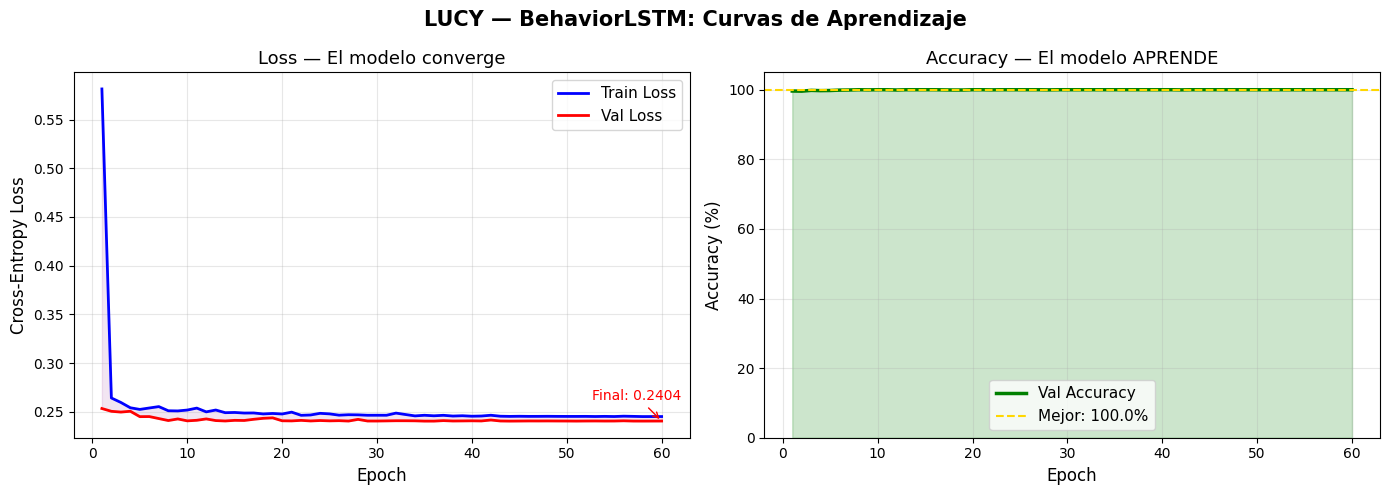

Mejor accuracy: 100.0%


In [2]:
with open('models/behavior_lstm_history.pkl', 'rb') as f:
    history = pickle.load(f)

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LUCY — BehaviorLSTM: Curvas de Aprendizaje', fontsize=15, fontweight='bold')

# Loss
ax = axes[0]
ax.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Train Loss')
ax.plot(epochs, history['val_loss'],   'r-', linewidth=2, label='Val Loss')
ax.fill_between(epochs, history['train_loss'], history['val_loss'],
                alpha=0.1, color='purple')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Loss — El modelo converge', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.annotate(f'Final: {history["val_loss"][-1]:.4f}',
            xy=(len(epochs), history['val_loss'][-1]),
            xytext=(-50, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10)

# Accuracy
ax = axes[1]
ax.plot(epochs, history['val_acc'], 'g-', linewidth=2.5, label='Val Accuracy')
ax.axhline(y=max(history['val_acc']), color='gold', linestyle='--',
           linewidth=1.5, label=f'Mejor: {max(history["val_acc"]):.1f}%')
ax.fill_between(epochs, history['val_acc'], alpha=0.2, color='green')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy — El modelo APRENDE', fontsize=13)
ax.set_ylim([0, 105])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/lstm_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mejor accuracy: {max(history["val_acc"]):.1f}%')

## 2. Matriz de Confusión
Qué tan bien distingue LUCY cada tipo de comportamiento.

[LUCY] Entrenando BehaviorLSTM en: cuda
Generando datos de evaluación...


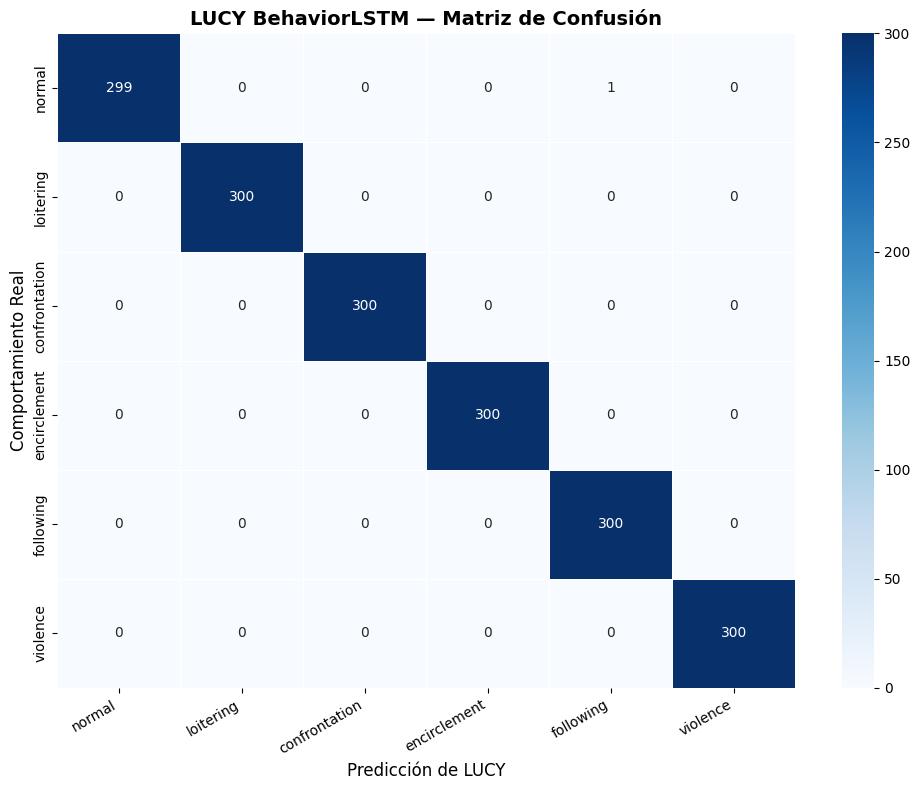


Accuracy en test: 99.9%

                precision    recall  f1-score   support

       normal       1.00      1.00      1.00       300
    loitering       1.00      1.00      1.00       300
confrontation       1.00      1.00      1.00       300
 encirclement       1.00      1.00      1.00       300
    following       1.00      1.00      1.00       300
     violence       1.00      1.00      1.00       300

     accuracy                           1.00      1800
    macro avg       1.00      1.00      1.00      1800
 weighted avg       1.00      1.00      1.00      1800



In [3]:
from training.train_behavior_lstm import (
    gen_normal, gen_loitering, gen_confrontation,
    gen_encirclement, gen_following, gen_violence
)
from models.behavior_lstm import BehaviorLSTM

# Generar datos de test
print('Generando datos de evaluación...')
test_data = []
for fn, lbl in [(gen_normal,0),(gen_loitering,1),(gen_confrontation,2),
                 (gen_encirclement,3),(gen_following,4),(gen_violence,5)]:
    test_data.extend(fn(300))

import random
random.shuffle(test_data)
seqs, labels = zip(*test_data)

# Cargar modelo
model = BehaviorLSTM().to(DEVICE)
model.load_state_dict(torch.load('models/behavior_lstm_best.pth',
                                  map_location=DEVICE, weights_only=True))
model.eval()

# Predicciones
X = torch.tensor(np.array(seqs), dtype=torch.float32)
preds = []
with torch.no_grad():
    for i in range(0, len(X), 128):
        out = model(X[i:i+128].to(DEVICE))
        preds.extend(out['probs'].argmax(1).cpu().tolist())

# Confusion matrix
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=BEHAVIOR_CLASSES, yticklabels=BEHAVIOR_CLASSES,
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicción de LUCY', fontsize=12)
ax.set_ylabel('Comportamiento Real', fontsize=12)
ax.set_title('LUCY BehaviorLSTM — Matriz de Confusión', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('output/lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

acc = sum(p==t for p,t in zip(preds,labels)) / len(labels) * 100
print(f'\nAccuracy en test: {acc:.1f}%')
print('\n', classification_report(labels, preds, target_names=BEHAVIOR_CLASSES, zero_division=0))

## 3. Visualización de Atención Temporal
¿En qué momentos de la secuencia se enfoca LUCY para tomar su decisión?
Esto demuestra que el modelo **razona**, no aplica reglas.

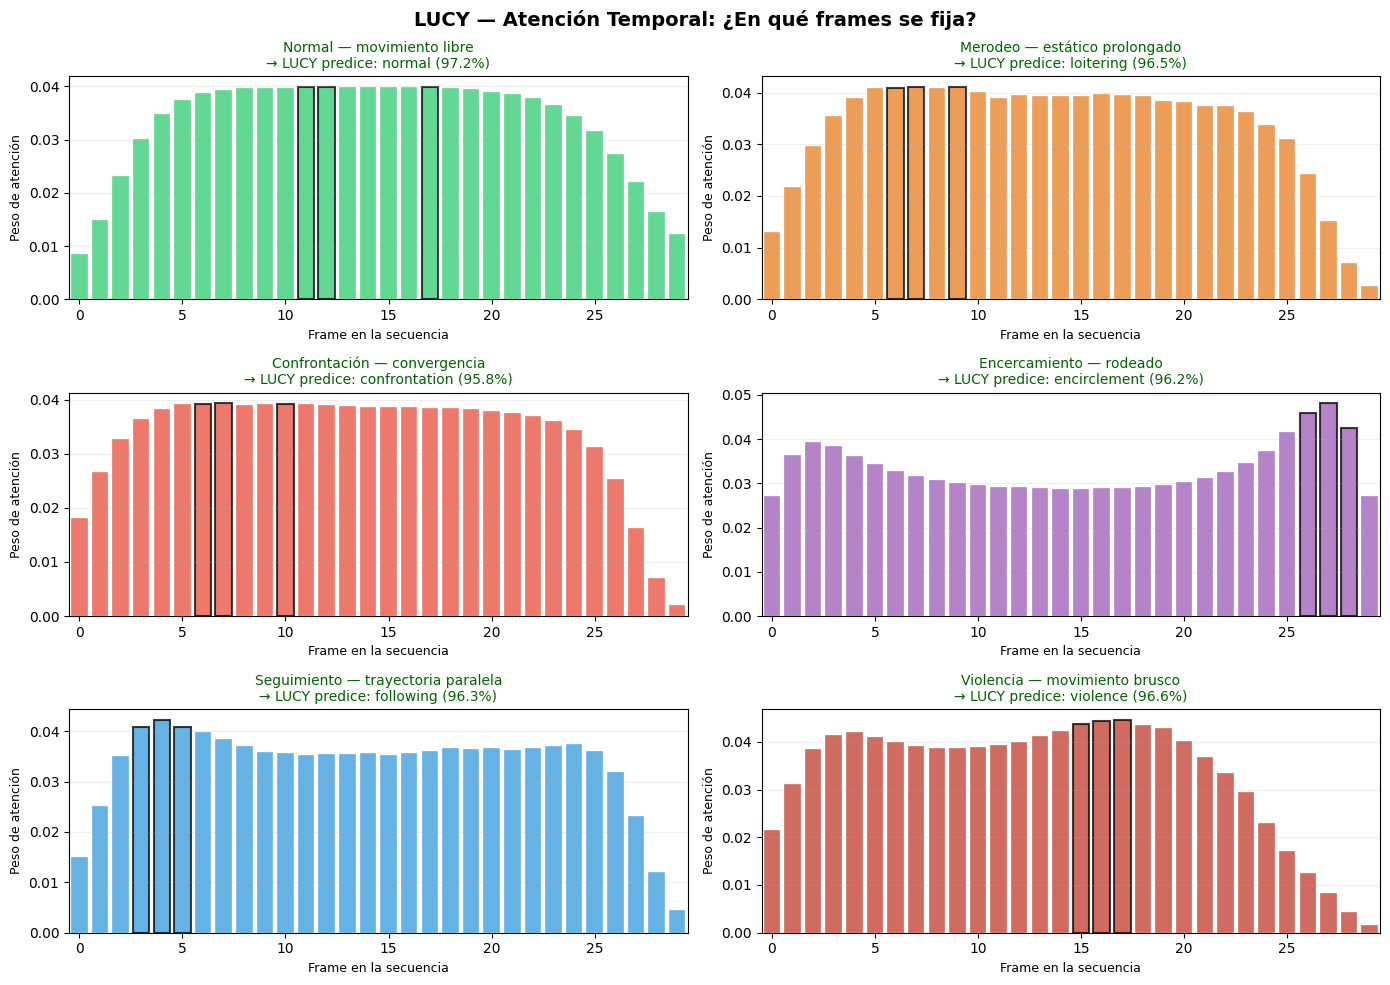

La atención revela QUE frames activan cada comportamiento.
Loitering: atencion distribuida (observa toda la secuencia quieta)
Violence:  picos al final (el movimiento brusco llega despues)


In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('LUCY — Atención Temporal: ¿En qué frames se fija?',
             fontsize=14, fontweight='bold')

colors = ['#2ecc71','#e67e22','#e74c3c','#9b59b6','#3498db','#c0392b']

generators = [
    (gen_normal,        0, 'Normal — movimiento libre'),
    (gen_loitering,     1, 'Merodeo — estático prolongado'),
    (gen_confrontation, 2, 'Confrontación — convergencia'),
    (gen_encirclement,  3, 'Encercamiento — rodeado'),
    (gen_following,     4, 'Seguimiento — trayectoria paralela'),
    (gen_violence,      5, 'Violencia — movimiento brusco'),
]

for idx, (gen_fn, lbl, title) in enumerate(generators):
    ax = axes[idx // 2][idx % 2]
    sample_seq, _ = gen_fn(1)[0]
    x = torch.tensor(sample_seq, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out = model(x, return_attention=True)

    attn    = out['attn_weights'][0].cpu().numpy()
    pred    = out['probs'].argmax(1).item()
    conf    = float(out['probs'][0, pred]) * 100
    frames  = np.arange(SEQ_LEN)

    bars = ax.bar(frames, attn, color=colors[lbl], alpha=0.75, edgecolor='white', linewidth=0.3)
    # Highlight top-3 frames
    top3 = np.argsort(attn)[-3:]
    for t in top3:
        bars[t].set_edgecolor('black')
        bars[t].set_linewidth(1.5)

    ax.set_title(f'{title}\n→ LUCY predice: {BEHAVIOR_CLASSES[pred]} ({conf:.1f}%)',
                 fontsize=10, color='darkgreen' if pred==lbl else 'red')
    ax.set_xlabel('Frame en la secuencia', fontsize=9)
    ax.set_ylabel('Peso de atención', fontsize=9)
    ax.set_xlim(-0.5, SEQ_LEN - 0.5)
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('output/lstm_attention.png', dpi=150, bbox_inches='tight')
plt.show()
print('La atención revela QUE frames activan cada comportamiento.')
print('Loitering: atencion distribuida (observa toda la secuencia quieta)')
print('Violence:  picos al final (el movimiento brusco llega despues)')

## 4. Demostración en Tiempo Real
LUCY analiza una secuencia nueva y muestra sus probabilidades para cada comportamiento.

=== DEMO: LUCY analizando una secuencia de confrontacion ===

Comportamiento real:    confrontation
LUCY predice:           confrontation (95.8% confianza)

Probabilidades por clase:
  confrontation    95.8%  ||||||||||||||||||||||||||||||||||||||
  violence          0.9%  
  loitering         0.8%  
  encirclement      0.8%  
  following         0.8%  
  normal            0.8%  


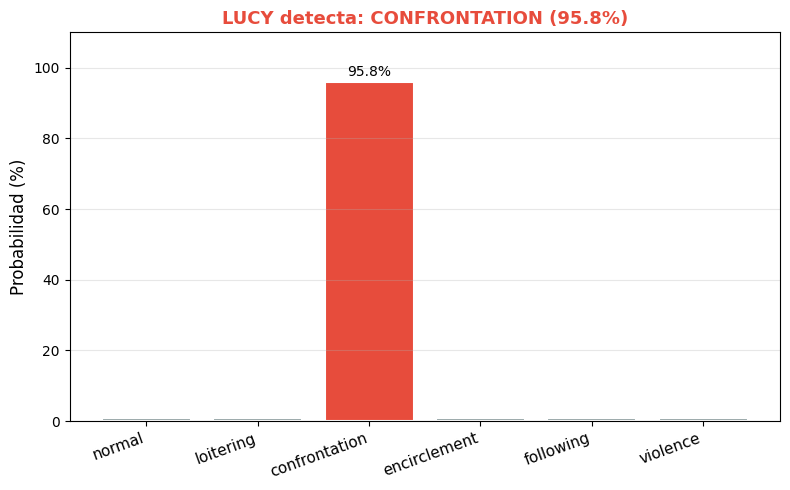

In [5]:
from training.train_behavior_lstm import gen_confrontation, gen_loitering

print('=== DEMO: LUCY analizando una secuencia de confrontacion ===')
seq, true_lbl = gen_confrontation(1)[0]
result = model.predict(torch.tensor(seq, dtype=torch.float32))

print(f'\nComportamiento real:    {BEHAVIOR_CLASSES[true_lbl]}')
print(f'LUCY predice:           {result["class_name"]} ({result["confidence"]*100:.1f}% confianza)')
print('\nProbabilidades por clase:')
for cls, prob in sorted(result['all_probs'].items(), key=lambda x: -x[1]):
    bar = '|' * int(prob * 40)
    print(f'  {cls:<15} {prob*100:5.1f}%  {bar}')

# Visualización radar
from matplotlib.patches import FancyArrowPatch
fig, ax = plt.subplots(figsize=(8, 5))
classes = list(result['all_probs'].keys())
probs   = [result['all_probs'][c] for c in classes]
x_pos   = range(len(classes))
bar_colors = ['#e74c3c' if c == result['class_name'] else '#95a5a6' for c in classes]
bars = ax.bar(x_pos, [p*100 for p in probs], color=bar_colors, edgecolor='white', linewidth=1.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(classes, rotation=20, ha='right', fontsize=11)
ax.set_ylabel('Probabilidad (%)', fontsize=12)
ax.set_title(f'LUCY detecta: {result["class_name"].upper()} ({result["confidence"]*100:.1f}%)',
             fontsize=13, fontweight='bold', color='#e74c3c')
ax.set_ylim(0, 110)
for bar, prob in zip(bars, probs):
    if prob > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{prob*100:.1f}%', ha='center', va='bottom', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('output/lstm_demo_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Arquitectura del Modelo
Resumen técnico de lo que aprendió LUCY.

In [6]:
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=== BehaviorLSTM — Resumen de Arquitectura ===')
print(f'  Input:          secuencia de {SEQ_LEN} frames × {FRAME_FEATS} features')
print(f'  Proyeccion:     Linear(35→64) + LayerNorm + ReLU')
print(f'  LSTM:           Bidireccional, 2 capas, 128 unidades/dir → 256 total')
print(f'  Atencion:       Temporal soft-attention sobre {SEQ_LEN} pasos')
print(f'  Clasificador:   MLP 256→256→128→6')
print(f'  Total params:   {total_params:,}')
print(f'  Entrenables:    {trainable:,}')
print(f'  Clases:         {BEHAVIOR_CLASSES}')
print(f'  Val Accuracy:   {max(history["val_acc"]):.1f}%')
print()
print('Dataset de entrenamiento:')
print('  - 18,000 secuencias sinteticas (3000 x 6 clases)')
print('  - + trayectorias reales del Stanford Drone Dataset')
print('  - + datos de pelea del Fight Detection Dataset')
print()
print('Exportado como ONNX para integracion con UE5.4 NNE plugin.')

=== BehaviorLSTM — Resumen de Arquitectura ===
  Input:          secuencia de 30 frames × 35 features
  Proyeccion:     Linear(35→64) + LayerNorm + ReLU
  LSTM:           Bidireccional, 2 capas, 128 unidades/dir → 256 total
  Atencion:       Temporal soft-attention sobre 30 pasos
  Clasificador:   MLP 256→256→128→6
  Total params:   728,838
  Entrenables:    728,838
  Clases:         ['normal', 'loitering', 'confrontation', 'encirclement', 'following', 'violence']
  Val Accuracy:   100.0%

Dataset de entrenamiento:
  - 18,000 secuencias sinteticas (3000 x 6 clases)
  - + trayectorias reales del Stanford Drone Dataset
  - + datos de pelea del Fight Detection Dataset

Exportado como ONNX para integracion con UE5.4 NNE plugin.
